<a href="https://colab.research.google.com/github/muhammadalihussnain/IBM-PROJECTS/blob/main/Quantum_first_program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install 'qiskit[visualization]' qiskit_ibm_runtime qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/

In [7]:
import sys
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.sampler import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.13.15
qiskit: 2.5.2
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.49.0


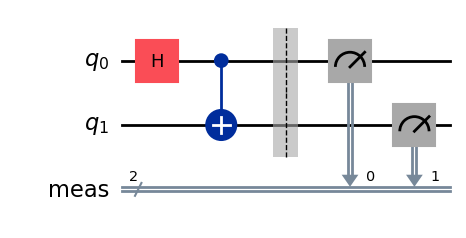

In [8]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0,1)
bell.measure_all()
bell.draw('mpl')

In [13]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

In [16]:
# uncommnet below once . but first obtain token from ibm cloud then run only once and then again comment below.

'''QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx",
    overwrite=True,
    set_as_default=True,
)
'''

'QiskitRuntimeService.save_account(\n    channel="ibm_quantum_platform",\n    token="6xVaPP7kie54r_bNDB06LL6jbqFiZzFFEA_NRIdDLafy",\n    overwrite=True,\n    set_as_default=True,\n)\n'

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="6xVaPP7kie54r_bNDB06LL6jbqFiZzFFEA_NRIdDLafy",
    overwrite=True,
    set_as_default=True,
)
service = QiskitRuntimeService(channel="ibm_quantum_platform")

In [10]:
service = QiskitRuntimeService(channel="ibm_quantum_platform")

qiskit_runtime_service.__init__:WARNING:2026-09-18 07:37:41,540: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


In [11]:
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_fez")
print(backend.name)

qiskit_runtime_service.backends:WARNING:2026-09-18 07:42:28,238: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-18 07:42:30,248: Using instance: open-instance, plan: open


ibm_fez


In [15]:
# uncomment these two lines to run this circuit on real QPUs

'''counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)'''

'counts = run_circuit_and_get_counts(bell, backend, shots=1000)\nplot_histogram(counts)'

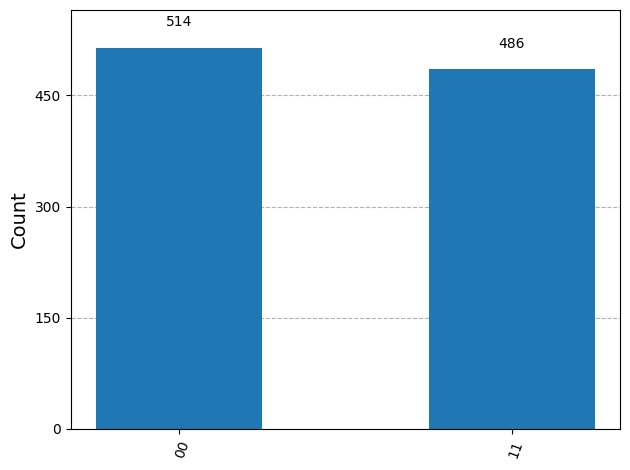

In [18]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)

plot_histogram(counts)